<a href="https://colab.research.google.com/github/saralopez08/Lenguaj_programaci-n-/blob/main/estadistica_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo de regresión lineal multiple
La regresión lineal múltiple es una extensión de la regresión lineal simple que permite modelar la relación entre una variable dependiente Y
 y múltiples variables independientes X1,X2,…,Xk
.

Este modelo surge cuando se desea explicar una respuesta utilizando más de un predictor, ya que muchos fenómenos del mundo real están influenciados por múltiples factores simultáneamente.

Se utiliza para:

Predecir valores de Y
 en función de varios predictores
Evaluar la influencia relativa de cada variable
Controlar el efecto de una variable mientras se examinan otras

In [4]:
# Datos
Horas_sueno <- c(3,2,1,6,8,8,9,5,6,6,7,8,7,8,5,3,2,1,6,8,8,9,5,6,6,7,8,7,8,5,8,8,8,7,7,6,7)
Hora_estudio <- c(2,3,1.5,4,3.5,5,6,2.5,7,8,1,4.5,5.5,6.5,7.5,3,2,4.2,3.8,5.8,6,8,4,5,5,6,9,6,8,4,8,8,9,7,6,5,4)
promedio <- c(60, 58, 50, 70, 75, 80, 85, 65, 78, 88, 55, 72, 76, 84, 90, 62, 59, 61, 74, 81, 83, 89, 68, 73, 75, 77, 91, 79, 86, 70, 87, 88, 89, 85, 84, 82, 80)

# Nueva variable: Horas de uso de internet
Horas_internet <- c(5,6,7,3,2,1,1,4,2,1,6,3,2,2,1,5,6,5,3,2,1,1,4,3,3,2,1,2,1,3,1,1,1,2,2,3,2)

# Crear data frame
datos <- data.frame(Horas_sueno, Hora_estudio, Horas_internet, promedio)

# Ver primeras filas
head(datos)

,Horas_sueno,Hora_estudio,Horas_internet,promedio
,<dbl>,<dbl>,<dbl>,<dbl>
1,3,2.0,5,60
2,2,3.0,6,58
3,1,1.5,7,50
4,6,4.0,3,70
5,8,3.5,2,75
6,8,5.0,1,80


##Correlación

In [20]:
cor(datos$Hora_estudio,datos$promedio)
mod<- lm(datos$promedio~datos$Hora_estudio)
summary(mod)

[1] 0.9197599


Call:
lm(formula = datos$promedio ~ datos$Hora_estudio)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.9375 -1.9899 -0.4661  2.4815 10.0101 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)         51.0374     1.9353   26.37  < 2e-16 ***
datos$Hora_estudio   4.7381     0.3418   13.86  8.8e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.405 on 35 degrees of freedom
Multiple R-squared:  0.846,	Adjusted R-squared:  0.8416 
F-statistic: 192.2 on 1 and 35 DF,  p-value: 8.804e-16


In [18]:
cor(datos$Horas_sueno, datos$promedio)
cor(datos$Horas_internet,datos$promedio)

[1] 0.777676

[1] -0.958969

#Modelo de Regresion Multiple

In [19]:
modelo <- lm(promedio ~ Horas_sueno + Hora_estudio + Horas_internet, data = datos)
#promedio = 74.3+0.25*horas_sueño + 1.94*horas_estudio - 3.77*horas-internet     (m1=0.25 , m2=1.94, m3=-3.77)
#prueba de hipoteiss, tengo 4 parametros (m1=b1, m2=b2...)
#p_value 3.73e-15 <0.05 se rechaza la hipotesis h1:b0 =/0

# Resumen del modelo
summary(modelo)


Call:
lm(formula = promedio ~ Horas_sueno + Hora_estudio + Horas_internet, 
    data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9257 -1.2724 -0.2788  0.8921  7.7416 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)     74.3183     5.4318  13.682 3.73e-15 ***
Horas_sueno      0.2575     0.3629   0.710    0.483    
Hora_estudio     1.9452     0.4088   4.758 3.75e-05 ***
Horas_internet  -3.7769     0.7098  -5.321 7.16e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.506 on 33 degrees of freedom
Multiple R-squared:  0.953,	Adjusted R-squared:  0.9487 
F-statistic:   223 on 3 and 33 DF,  p-value: < 2.2e-16


##Diagnostico del Modelo

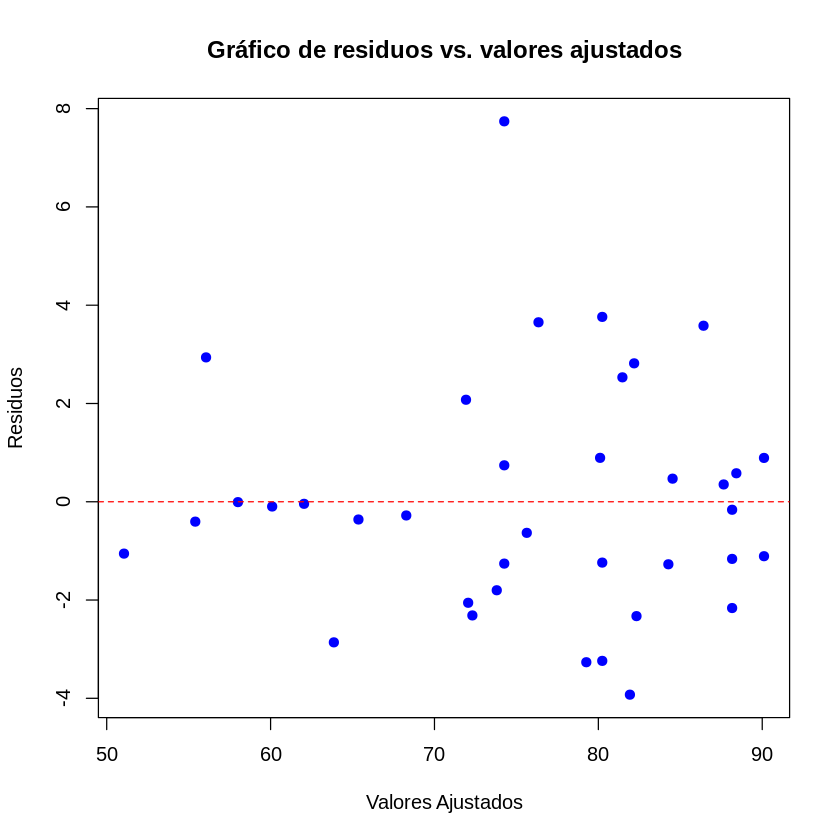

In [21]:
#Grafico de residuos vs valores ajustados

plot(modelo$fitted.values, resid(modelo),
     xlab = "Valores Ajustados",
     ylab = "Residuos",
     main = "Gráfico de residuos vs. valores ajustados",
     pch = 19, col = "blue")
abline(h = 0, col = "red", lty = 2)